Librerías y Funciones propias:

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

import numpy as np
import matplotlib.pyplot as plt
from helpers.overlapSave import overlapSaveBlock
from helpers.adapt import adapt
from helpers.room import room
from helpers.generateRirs import generateRirs

Simulation:

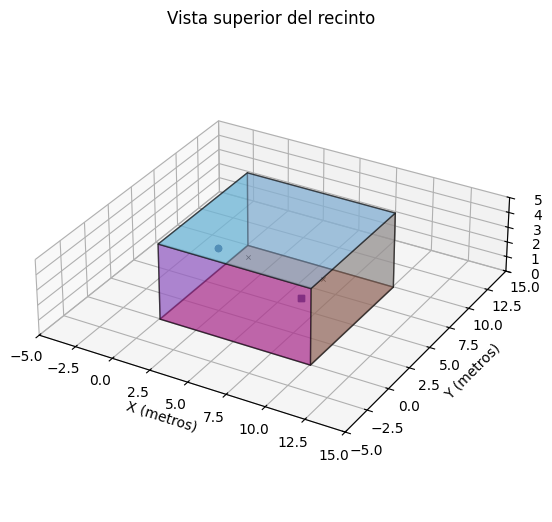

In [2]:
fs = 48000
room = room(fs)

Obtain RIRs:

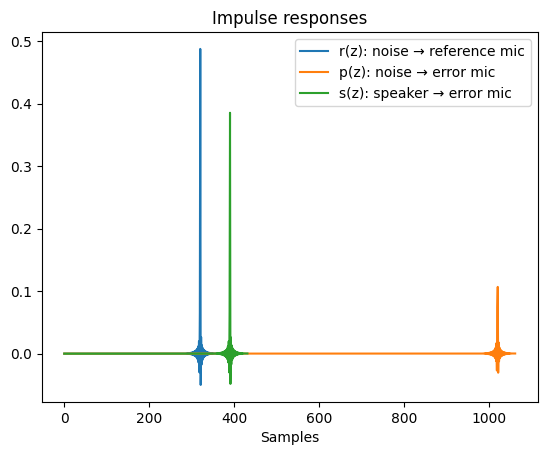

Delay R: 6.666666666666667 ms
Delay P: 21.25 ms
Delay S: 8.125 ms
In order to comply with causality, computational time must be smaller than: 6.458333333333332 ms
Reference path length:  362
Primary path length:  1062
Secondary path length:  432


In [3]:
rir_r, rir_p, rir_s = generateRirs(fs, room)

MFxLMS: 

This is a pure MFxLMS implementation which uses a perfect model of the secondary path.

T12 detected
T12 detected
T12 detected
T12 detected
T12 detected
T12 detected
T12 detected
T12 detected
T12 detected
T12 detected
T12 detected
T12 detected
T12 detected
T12 detected


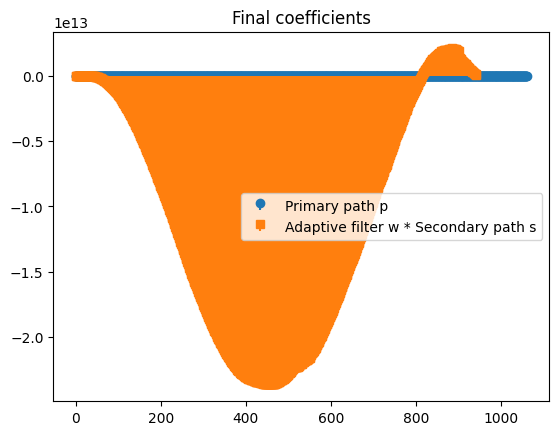

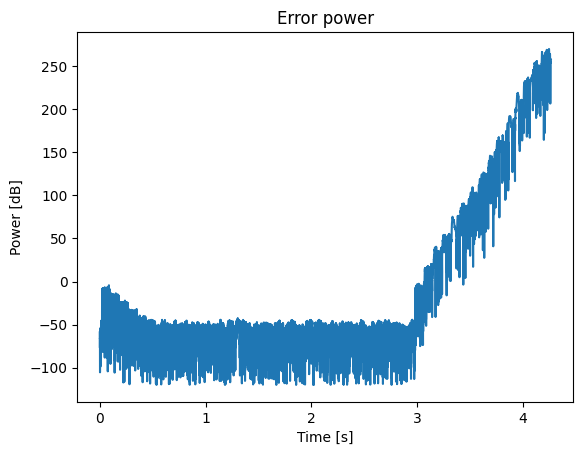

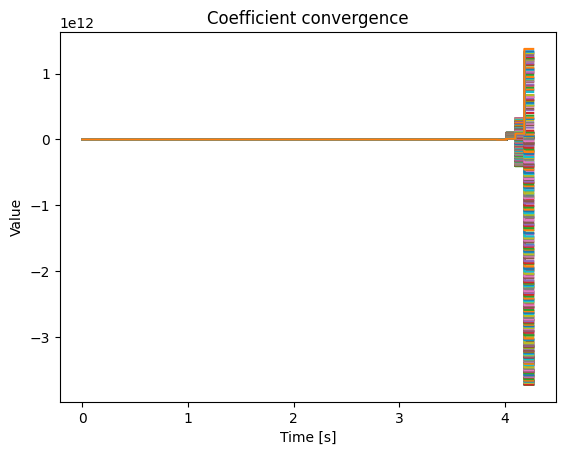

In [ ]:
np.random.seed(0)

# Block and signal definition
blocklength = 4096
nBlocks = 50
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
x = np.random.randn(N)

# Adaptive filter initialization (its spectrum has to be recalculated inside the loop)
mu = 25
M_w = 512
w = np.zeros(M_w)
N_w = blocklength + M_w - 1
wBuffer = np.zeros(M_w - 1)
wOutputBlocks = []

wHatBuffer = np.zeros(M_w - 1)
wHatOutputBlocks = []

# Primary path
p = rir_p
M_p = len(p)
N_p = blocklength + M_p - 1
pSpectrum = np.fft.rfft(p, N_p)
pBuffer = np.zeros(M_p - 1)
pOutputBlocks = []

# Secondary path
s = rir_s 
M_s = len(s)
N_s = blocklength + M_s - 1
sSpectrum = np.fft.rfft(s, N_s)
sBuffer = np.zeros(M_s - 1)
sOutputBlocks = []

# Secondary path aproximation
sHat = s
M_sHat = len(sHat)
N_sHat = blocklength + M_sHat - 1
sHatSpectrum = np.fft.rfft(sHat, N_sHat)
sHatBuffer = np.zeros(M_sHat - 1)
sHatOutputBlocks = []

sHatPrimeBuffer = np.zeros(M_sHat - 1)
sHatPrimeOutputBlocks = []

# Noise source path
r = rir_r
M_r = len(r)
N_r = blocklength + M_r - 1
rSpectrum = np.fft.rfft(r, N_r)
rBuffer = np.zeros(M_r - 1)
rOutputBlocks = []

# History
e_hist = np.zeros(N)
mean_e_p_hist = np.zeros(nBlocks)
w_hist = np.zeros((N, M_w))

for k in range(nBlocks):

    # Block samples of X
    xBlock = x[k*blocklength : (k+1)*blocklength]

    # Reference mic signal
    rBlockOutput, rBuffer = overlapSaveBlock(xBlock, rSpectrum, rBuffer, M_r, N_r)
    rOutputBlocks.append(rBlockOutput)

    # Primary path P(z)
    pBlockOutput, pBuffer = overlapSaveBlock(xBlock, pSpectrum, pBuffer, M_p, N_p)
    pOutputBlocks.append(pBlockOutput)

    # Adaptive filter W(z)
    wSpectrum = np.fft.rfft(w, N_w)
    yBlockOutput, wBuffer = overlapSaveBlock(rBlockOutput, wSpectrum, wBuffer, M_w, N_w)
    wOutputBlocks.append(yBlockOutput)
    
    # Secondary path S(z)
    fyBlockOutput, sBuffer = overlapSaveBlock(yBlockOutput, sSpectrum, sBuffer, M_s, N_s)
    sOutputBlocks.append(fyBlockOutput)

    e = pBlockOutput - fyBlockOutput

    # Reconstruct desired signal 
    yPrimeBlockOutput, sHatPrimeBuffer = overlapSaveBlock(yBlockOutput, sHatSpectrum, sHatPrimeBuffer, M_sHat, N_sHat)
    sHatPrimeOutputBlocks.append(yPrimeBlockOutput)

    dHat = e + yPrimeBlockOutput

    # Reconstruct error signal
    fxBlockOutput, sHatBuffer = overlapSaveBlock(rBlockOutput, sHatSpectrum, sHatBuffer, M_sHat, N_sHat)
    sHatOutputBlocks.append(fxBlockOutput)

    yHatBlockOutput, wHatBuffer = overlapSaveBlock(fxBlockOutput, wSpectrum, wHatBuffer, M_w, N_w)
    wHatOutputBlocks.append(yHatBlockOutput)

    eHat = dHat - yHatBlockOutput

    # LMS algorithm
    w = adapt(fxBlockOutput, eHat, M_w, blocklength, w, mu)

    # History
    e_hist[k * blocklength:(k+1) * blocklength] = e
    w_hist[k * blocklength:(k+1) * blocklength, :] = w

plt.figure()
plt.stem(p, linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.stem(np.convolve(w, s)[:len(p)], linefmt='C1-', markerfmt='C1s', basefmt=" ")
plt.legend(['Primary path p', 'Adaptive filter w * Secondary path s'])
plt.title('Final coefficients')
plt.show()

plt.figure()
plt.plot(t, 10*np.log10(e_hist**2 + 1e-12))
plt.title('Error power')
plt.xlabel('Time [s]')
plt.ylabel('Power [dB]')
plt.show()

plt.figure()
for k in range(M_w):
    plt.plot(t, w_hist[:, k])
plt.title('Coefficient convergence')
plt.xlabel('Time [s]')
plt.ylabel('Value')
plt.show()


This algorithm removes the lag between the filter coefficients and the error signal when adapting, since it adapts the dummy filter, which is aligned with the estimated error signal. This allows for greater step sizes (See Elliot page 137).